# Strict-Full vs Strict Baseline Comparison with pAUC@88

이 notebook은 `Strict-Full (초기 Strict 후보)`와 `Strict (최종 메인 세트)`를 같은 split, 같은 전처리, 같은 baseline 설정 위에서 직접 비교하기 위한 실험 notebook이다.

## 실험 목적
1. 더 넓은 현실형 후보였던 `Strict-Full`과 최종 채택된 `Strict`의 성능 차이를 직접 확인한다.
2. 이번 비교의 기본 평가지표는 `pAUC@TPR>=0.88`로 둔다.
3. 높은 민감도 구간에서 `Strict`가 실제로 더 단단한지 확인한다.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

FONT_CANDIDATES = [
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
    '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc',
]
for font_path in FONT_CANDIDATES:
    if Path(font_path).exists():
        from matplotlib import font_manager as fm
        font_name = fm.FontProperties(fname=font_path).get_name()
        mpl.rcParams['font.family'] = font_name
        break
mpl.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

base_dir = Path('/home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024')
input_dir = base_dir / 'model_inputs'
out_dir = base_dir / 'modeling' / 'strict_full_vs_final_strict_baseline'
out_dir.mkdir(parents=True, exist_ok=True)

PRIMARY_MIN_TPR = 0.88
SECONDARY_MIN_TPR = 0.80
PRIMARY_MAX_FPR = 1 - PRIMARY_MIN_TPR
SECONDARY_MAX_FPR = 1 - SECONDARY_MIN_TPR
DISPLAY_NAME = {
    'strict_full': 'Strict-Full',
    'strict_full_ablation': 'Strict-Full ablation',
    'final_strict': 'Strict',
}
DISPLAY_COLOR = {
    'strict_full': '#d55e00',
    'final_strict': '#0072b2',
}

strict_full_paths = {
    'train': input_dir / 'isic2024_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_strict_internal_test_input.parquet',
}
final_strict_paths = {
    'train': input_dir / 'isic2024_final_strict_train_input.parquet',
    'validation': input_dir / 'isic2024_final_strict_validation_input.parquet',
    'internal_test': input_dir / 'isic2024_final_strict_internal_test_input.parquet',
}
meta_cols = ['isic_id', 'patient_id', 'target', 'split']
random_state = 42

print('input_dir =', input_dir)
print('out_dir =', out_dir)
print('strict_full train exists =', strict_full_paths['train'].exists())
print('final strict train exists =', final_strict_paths['train'].exists())
print('primary metric = pAUC@TPR>=', PRIMARY_MIN_TPR)


input_dir = /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/model_inputs
out_dir = /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_baseline
strict_full train exists = True
final strict train exists = True
primary metric = pAUC@TPR>= 0.88


## 1. 입력 테이블 로드와 기본 구조 확인

### 목적
코드 셀에서는 `Strict-Full`과 `Strict` 입력 테이블을 읽고, split별 행 수와 컬럼 수를 먼저 확인합니다.

여기서 가장 먼저 확인할 것은 두 입력 세트가 **같은 샘플을 같은 split으로 담고 있는지**입니다. 그래야 이후 성능 차이를 feature 차이로 해석할 수 있습니다.


,regime_display,split,n_rows,n_total_columns,n_feature_columns,n_positive_rows,positive_ratio_pct
0,Strict-Full,train,280335,66,62,270,0.096313
1,Strict-Full,validation,65684,66,62,57,0.086779
2,Strict-Full,internal_test,55040,66,62,66,0.119913
3,Strict,train,280335,55,51,270,0.096313
4,Strict,validation,65684,55,51,57,0.086779
5,Strict,internal_test,55040,55,51,66,0.119913


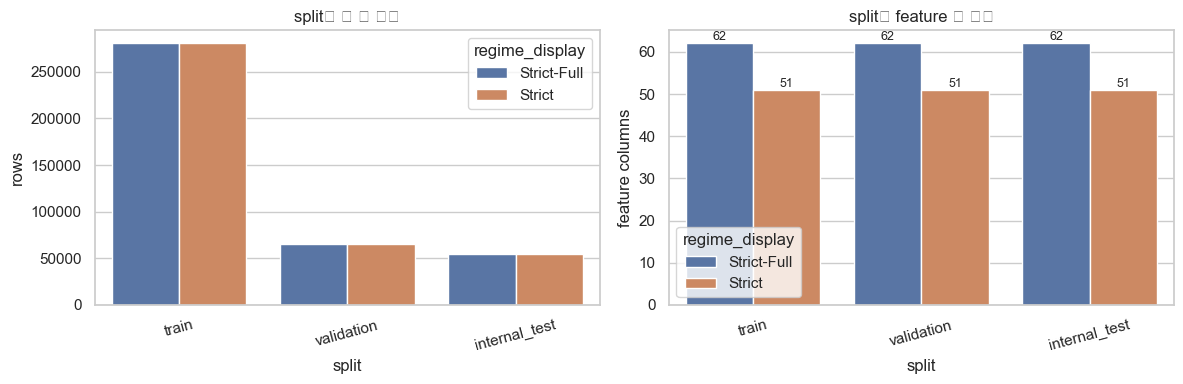

In [2]:
strict_full_data = {split: pd.read_parquet(path) for split, path in strict_full_paths.items()}
final_strict_data = {split: pd.read_parquet(path) for split, path in final_strict_paths.items()}

summary_rows = []
for regime_name, regime_data in [('strict_full', strict_full_data), ('final_strict', final_strict_data)]:
    for split, df in regime_data.items():
        feature_cols = [c for c in df.columns if c not in meta_cols]
        summary_rows.append({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'split': split,
            'n_rows': len(df),
            'n_total_columns': df.shape[1],
            'n_feature_columns': len(feature_cols),
            'n_positive_rows': int(df['target'].sum()),
            'positive_ratio_pct': round(df['target'].mean() * 100, 6),
        })

input_summary_df = pd.DataFrame(summary_rows)
display(input_summary_df[['regime_display', 'split', 'n_rows', 'n_total_columns', 'n_feature_columns', 'n_positive_rows', 'positive_ratio_pct']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=input_summary_df, x='split', y='n_rows', hue='regime_display', ax=axes[0])
axes[0].set_title('split별 행 수 비교')
axes[0].set_xlabel('split')
axes[0].set_ylabel('rows')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=input_summary_df, x='split', y='n_feature_columns', hue='regime_display', ax=axes[1])
axes[1].set_title('split별 feature 수 비교')
axes[1].set_xlabel('split')
axes[1].set_ylabel('feature columns')
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', fontsize=9)
plt.tight_layout()
plt.show()


### 해석 포인트
1. `Strict-Full`과 `Strict`는 행 수와 positive row 수가 같아야 합니다.
2. 두 세트의 차이는 feature 수에서만 나타나야 합니다.
3. 이 조건이 만족되면 이후 성능 차이를 feature 차이로 해석하기 쉬워집니다.


## 2. 샘플 정렬 일치 여부 점검

### 목적
코드 셀에서는 각 split에서 `isic_id`, `patient_id`, `target`, `split`이 두 입력 세트에서 완전히 같은지 확인합니다.

이 검사가 통과되어야 `Strict-Full`과 `Strict` 비교가 공정하다고 말할 수 있습니다.


In [3]:
alignment_rows = []
for split in ['train', 'validation', 'internal_test']:
    left = strict_full_data[split][meta_cols].reset_index(drop=True)
    right = final_strict_data[split][meta_cols].reset_index(drop=True)
    same_order = left.equals(right)
    same_isic_set = set(left['isic_id']) == set(right['isic_id'])
    alignment_rows.append({
        'split': split,
        'same_row_order': same_order,
        'same_isic_id_set': same_isic_set,
        'same_n_rows': len(left) == len(right),
    })
alignment_df = pd.DataFrame(alignment_rows)
display(alignment_df)


,split,same_row_order,same_isic_id_set,same_n_rows
0,train,True,True,True
1,validation,True,True,True
2,internal_test,True,True,True


### 해석 포인트
모든 split에서 `same_row_order=True`이면, 이후 예측값 비교나 error analysis를 할 때도 두 세트를 같은 행 기준으로 나란히 볼 수 있습니다.


## 3. 동일한 baseline 설정 정의

### 목적
코드 셀에서는 두 feature set에 똑같이 적용할 baseline 설정을 고정합니다.

이번 baseline은 해석이 쉬운 쪽을 우선해서 아래처럼 둡니다.
1. 숫자형: `median` 대체 후 `StandardScaler`
2. 범주형: `most_frequent` 대체 후 `OneHotEncoder`
3. 모델: `LogisticRegression`
4. class imbalance 대응: `class_weight='balanced'`

평가 규칙은 임상적 목표에 맞춰 바꿉니다.
1. 기본 평가지표: `pAUC@TPR>=0.88`
2. 보조 지표: `pAUC@TPR>=0.80`, `ROC AUC`, `Average Precision`
3. threshold는 `validation`에서 `TPR>=0.88`을 만족하면서 specificity가 가장 높은 값으로 고릅니다.


In [4]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def build_pipeline(feature_df: pd.DataFrame):
    categorical_cols = feature_df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    numeric_cols = [c for c in feature_df.columns if c not in categorical_cols]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_one_hot_encoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_cols),
            ('cat', categorical_pipeline, categorical_cols),
        ],
        remainder='drop',
        sparse_threshold=0,
    )

    model = LogisticRegression(
        solver='saga',
        penalty='l2',
        C=1.0,
        max_iter=500,
        tol=1e-3,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1,
    )

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    return pipeline, numeric_cols, categorical_cols


def p_auc_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    # pAUC@TPR>=min_tpr = ∫_0^{max_fpr} TPR(FPR) dFPR
    # where max_fpr = 1 - min_tpr.
    # For min_tpr=0.88, we only integrate the ROC curve up to FPR=0.12.
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    if len(np.unique(y_true)) != 2:
        return np.nan
    v_gt = np.abs(y_true - 1)
    v_pred = np.abs(y_prob - 1)
    max_fpr = abs(1 - min_tpr)
    fpr, tpr, _ = roc_curve(v_gt, v_pred)
    if max_fpr <= 0 or max_fpr > 1:
        raise ValueError(f'Expected min_tpr in (0, 1], got {min_tpr}')
    stop = np.searchsorted(fpr, max_fpr, 'right')
    if stop <= 1:
        return float(max_fpr * tpr[min(stop - 1, len(tpr) - 1)])
    if stop >= len(fpr):
        return float(np.trapz(tpr, fpr))
    tpr_cut = np.append(tpr[:stop], np.interp(max_fpr, [fpr[stop - 1], fpr[stop]], [tpr[stop - 1], tpr[stop]]))
    fpr_cut = np.append(fpr[:stop], max_fpr)
    return float(np.trapz(tpr_cut, fpr_cut))


def choose_threshold_by_min_tpr(y_true, y_prob, min_tpr=PRIMARY_MIN_TPR):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    eligible = np.where(tpr >= min_tpr)[0]
    if len(eligible) == 0:
        best_idx = int(np.argmax(tpr - fpr))
    else:
        best_idx = eligible[np.argmin(fpr[eligible])]
    return float(thresholds[best_idx]), float(tpr[best_idx]), float(1 - fpr[best_idx])


def specificity_score(y_true, y_pred):
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return tn / max(tn + fp, 1)


def evaluate_predictions(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'pauc_tpr88': float(p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)),
        'pauc_tpr80': float(p_auc_tpr(y_true, y_prob, SECONDARY_MIN_TPR)),
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'average_precision': float(average_precision_score(y_true, y_prob)),
        'log_loss': float(log_loss(y_true, y_prob, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_prob)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'balanced_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'specificity': float(specificity_score(y_true, y_pred)),
        'predicted_positive_rate': float(y_pred.mean()),
    }


## 4. Strict-Full / Strict 학습과 성능 평가

### 목적
코드 셀에서는 두 입력 세트를 같은 설정으로 학습하고, `validation`과 `internal_test`에서 성능을 비교합니다.

평가 방식:
1. 기본 평가지표는 `pAUC@TPR>=0.88`입니다.
2. 보조 지표로 `pAUC@TPR>=0.80`, `ROC AUC`, `Average Precision`을 함께 봅니다.
3. threshold는 `validation`에서 `TPR>=0.88`을 만족하면서 specificity가 가장 높은 값으로 고릅니다.
4. threshold-dependent metric은 그 clinical threshold를 `internal_test`에도 그대로 적용해 봅니다.


In [5]:
regime_inputs = {
    'strict_full': strict_full_data,
    'final_strict': final_strict_data,
}

all_metrics = []
all_predictions = []
coef_tables = []
trained_objects = {}

for regime_name, regime_data in regime_inputs.items():
    train_df = regime_data['train'].copy()
    val_df = regime_data['validation'].copy()
    test_df = regime_data['internal_test'].copy()

    feature_cols = [c for c in train_df.columns if c not in meta_cols]

    X_train = train_df[feature_cols]
    y_train = train_df['target'].astype(int)
    X_val = val_df[feature_cols]
    y_val = val_df['target'].astype(int)
    X_test = test_df[feature_cols]
    y_test = test_df['target'].astype(int)

    pipeline, numeric_cols, categorical_cols = build_pipeline(X_train)
    pipeline.fit(X_train, y_train)

    val_prob = pipeline.predict_proba(X_val)[:, 1]
    test_prob = pipeline.predict_proba(X_test)[:, 1]
    best_threshold, val_selected_tpr, val_selected_specificity = choose_threshold_by_min_tpr(y_val.to_numpy(), val_prob, PRIMARY_MIN_TPR)

    for split_name, df_split, y_true, y_prob in [
        ('validation', val_df, y_val.to_numpy(), val_prob),
        ('internal_test', test_df, y_test.to_numpy(), test_prob),
    ]:
        metrics = evaluate_predictions(y_true, y_prob, best_threshold)
        metrics.update({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'split': split_name,
            'threshold_from_validation_tpr88': best_threshold,
            'validation_selected_tpr': val_selected_tpr,
            'validation_selected_specificity': val_selected_specificity,
            'n_rows': len(df_split),
            'n_positive_rows': int(df_split['target'].sum()),
            'n_feature_columns': len(feature_cols),
            'n_numeric_features': len(numeric_cols),
            'n_categorical_features': len(categorical_cols),
        })
        all_metrics.append(metrics)

        pred_df = df_split[meta_cols].copy()
        pred_df['regime'] = regime_name
        pred_df['regime_display'] = DISPLAY_NAME.get(regime_name, regime_name)
        pred_df['pred_proba'] = y_prob
        pred_df['pred_label'] = (y_prob >= best_threshold).astype(int)
        all_predictions.append(pred_df)

    try:
        feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
        coef_df = pd.DataFrame({
            'regime': regime_name,
            'regime_display': DISPLAY_NAME.get(regime_name, regime_name),
            'feature_name': feature_names,
            'coefficient': pipeline.named_steps['model'].coef_.ravel(),
        })
        coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
        coef_tables.append(coef_df)
    except Exception:
        pass

    trained_objects[regime_name] = {
        'pipeline': pipeline,
        'feature_cols': feature_cols,
    }

metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True)
coef_df = pd.concat(coef_tables, ignore_index=True) if coef_tables else pd.DataFrame()

metrics_path = out_dir / 'strict_full_vs_final_strict_baseline_metrics.csv'
pred_path = out_dir / 'strict_full_vs_final_strict_predictions.parquet'
coef_path = out_dir / 'strict_full_vs_final_strict_coefficients.csv'

metrics_df.to_csv(metrics_path, index=False)
predictions_df.to_parquet(pred_path, index=False)
if not coef_df.empty:
    coef_df.to_csv(coef_path, index=False)

print('saved ->', metrics_path)
print('saved ->', pred_path)
print('saved ->', coef_path)
display(metrics_df.round(6))


saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_baseline/strict_full_vs_final_strict_baseline_metrics.csv
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_baseline/strict_full_vs_final_strict_predictions.parquet
saved -> /home/junkim2603a/proj/paper_ajou_dev/artifacts/eda/isic2024/modeling/strict_full_vs_final_strict_baseline/strict_full_vs_final_strict_coefficients.csv


,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,log_loss,brier_score,precision,recall,f1,balanced_accuracy,...,regime_display,split,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,n_rows,n_positive_rows,n_feature_columns,n_numeric_features,n_categorical_features
0,0.000000,0.088497,0.856360,0.005446,3.970914,0.162096,0.001852,0.894737,0.003696,0.737912,...,Strict-Full,validation,0.000000,0.894737,0.581087,65684,57,62,57,5
1,0.000000,0.000000,0.748077,0.005833,3.567825,0.155061,0.002043,0.742424,0.004074,0.653491,...,Strict-Full,internal_test,0.000000,0.894737,0.581087,55040,66,62,57,5
2,0.072412,0.138182,0.895124,0.005437,5.801539,0.224648,0.003954,0.894737,0.007873,0.849489,...,Strict,validation,0.999567,0.894737,0.804242,65684,57,51,46,5
3,0.072346,0.136532,0.889981,0.008221,5.036650,0.202525,0.005444,0.787879,0.010813,0.807535,...,Strict,internal_test,0.999567,0.894737,0.804242,55040,66,51,46,5


### 해석 포인트
1. 가장 먼저 `pAUC@TPR>=0.88`을 봅니다. 이것이 이번 notebook의 기본 평가지표입니다.
2. 그 다음 `pAUC@TPR>=0.80`, `ROC AUC`, `Average Precision`을 보조로 봅니다.
3. threshold-dependent metric은 `TPR>=0.88`을 만족하도록 잡은 clinical threshold 위에서 읽습니다.
4. `Strict`가 비슷하거나 더 좋다면, 더 단순한 세트를 메인으로 삼는 근거가 강해집니다.


## 5. 성능 비교 시각화

### 목적
코드 셀에서는 metric 표를 split별로 다시 정리하고, 전체 ROC와 고민감도 구간 ROC를 함께 보여줍니다.

이번 시각화의 초점은 `pAUC@TPR>=0.88` 영역입니다.


,regime_display,split,pauc_tpr88,pauc_tpr80,roc_auc,average_precision,f1,recall,precision,specificity,balanced_accuracy,threshold_from_validation_tpr88,validation_selected_tpr,validation_selected_specificity,n_feature_columns
0,Strict-Full,validation,0.000000,0.088497,0.856360,0.005446,0.003696,0.894737,0.001852,0.581087,0.737912,0.000000,0.894737,0.581087,62
1,Strict-Full,internal_test,0.000000,0.000000,0.748077,0.005833,0.004074,0.742424,0.002043,0.564558,0.653491,0.000000,0.894737,0.581087,62
2,Strict,validation,0.072412,0.138182,0.895124,0.005437,0.007873,0.894737,0.003954,0.804242,0.849489,0.999567,0.894737,0.804242,51
3,Strict,internal_test,0.072346,0.136532,0.889981,0.008221,0.010813,0.787879,0.005444,0.827191,0.807535,0.999567,0.894737,0.804242,51


pauc_tpr88             pauc_tpr80               roc_auc  \
regime_display     Strict Strict-Full     Strict Strict-Full    Strict   
split                                                                    
internal_test    0.072346         0.0   0.136532    0.000000  0.889981   
validation       0.072412         0.0   0.138182    0.088497  0.895124   

                           average_precision                    f1  \
regime_display Strict-Full            Strict Strict-Full    Strict   
split                                                                
internal_test     0.748077          0.008221    0.005833  0.010813   
validation        0.856360          0.005437    0.005446  0.007873   

                              recall             precision              \
regime_display Strict-Full    Strict Strict-Full    Strict Strict-Full   
split                                                                    
internal_test     0.004074  0.787879    0.742424  0.005444    0.002043   
validation        0.003696  0.894737    0.894737  0.003954    0.001852   

               specificity              
regime_display      Strict Strict-Full  
split                                   
internal_test     0.827191    0.564558  
validation        0.804242    0.581087

,split,delta_pauc_tpr88_final_minus_full,delta_pauc_tpr80_final_minus_full,delta_roc_auc_final_minus_full,delta_average_precision_final_minus_full,delta_f1_final_minus_full,delta_recall_final_minus_full,delta_precision_final_minus_full,delta_specificity_final_minus_full
0,validation,0.072412,0.049685,0.038765,-0.000008,0.004178,0.000000,0.002102,0.223155
1,internal_test,0.072346,0.136532,0.141904,0.002388,0.006739,0.045455,0.003401,0.262633


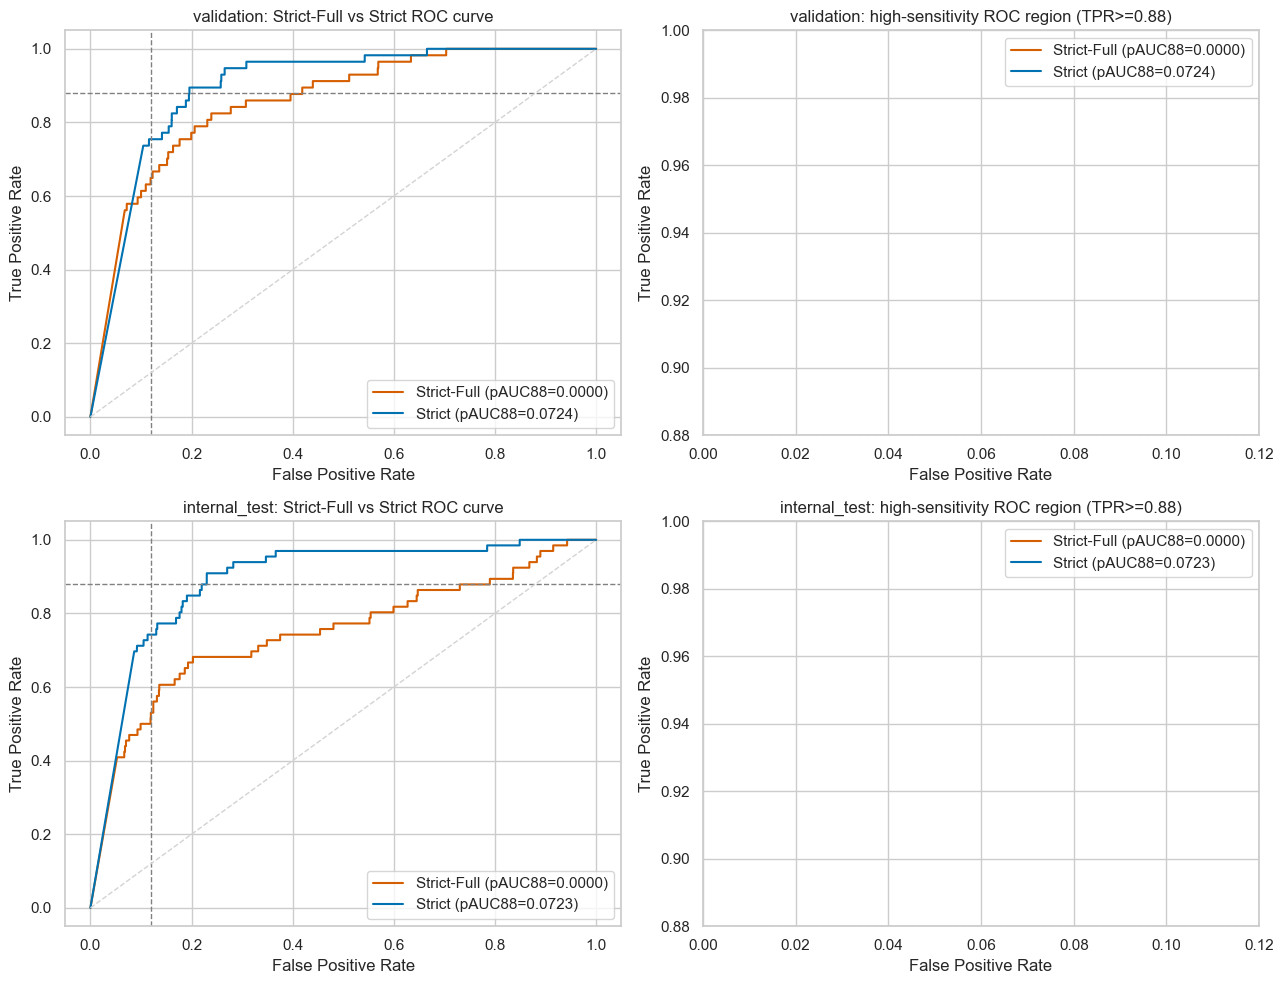

In [6]:
metrics_display_cols = [
    'regime_display', 'split', 'pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision',
    'f1', 'recall', 'precision', 'specificity', 'balanced_accuracy',
    'threshold_from_validation_tpr88', 'validation_selected_tpr', 'validation_selected_specificity',
    'n_feature_columns'
]
display(metrics_df[metrics_display_cols].round(6))

pivot_df = metrics_df.pivot(index='split', columns='regime_display', values=['pauc_tpr88', 'pauc_tpr80', 'roc_auc', 'average_precision', 'f1', 'recall', 'precision', 'specificity'])
display(pivot_df.round(6))

delta_rows = []
for split in metrics_df['split'].unique():
    full_row = metrics_df[(metrics_df['split'] == split) & (metrics_df['regime'] == 'strict_full')].iloc[0]
    final_row = metrics_df[(metrics_df['split'] == split) & (metrics_df['regime'] == 'final_strict')].iloc[0]
    delta_rows.append({
        'split': split,
        'delta_pauc_tpr88_final_minus_full': final_row['pauc_tpr88'] - full_row['pauc_tpr88'],
        'delta_pauc_tpr80_final_minus_full': final_row['pauc_tpr80'] - full_row['pauc_tpr80'],
        'delta_roc_auc_final_minus_full': final_row['roc_auc'] - full_row['roc_auc'],
        'delta_average_precision_final_minus_full': final_row['average_precision'] - full_row['average_precision'],
        'delta_f1_final_minus_full': final_row['f1'] - full_row['f1'],
        'delta_recall_final_minus_full': final_row['recall'] - full_row['recall'],
        'delta_precision_final_minus_full': final_row['precision'] - full_row['precision'],
        'delta_specificity_final_minus_full': final_row['specificity'] - full_row['specificity'],
    })
delta_df = pd.DataFrame(delta_rows)
display(delta_df.round(6))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for idx, split in enumerate(['validation', 'internal_test']):
    ax_roc = axes[idx, 0]
    ax_zoom = axes[idx, 1]
    for regime_name in ['strict_full', 'final_strict']:
        split_pred = predictions_df[(predictions_df['split'] == split) & (predictions_df['regime'] == regime_name)]
        y_true = split_pred['target'].to_numpy()
        y_prob = split_pred['pred_proba'].to_numpy()
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        pauc88 = p_auc_tpr(y_true, y_prob, PRIMARY_MIN_TPR)
        label = f"{DISPLAY_NAME.get(regime_name, regime_name)} (pAUC88={pauc88:.4f})"
        ax_roc.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])
        ax_zoom.plot(fpr, tpr, label=label, color=DISPLAY_COLOR[regime_name])

    for ax in [ax_roc, ax_zoom]:
        ax.axhline(PRIMARY_MIN_TPR, linestyle='--', color='gray', linewidth=1)
        ax.axvline(PRIMARY_MAX_FPR, linestyle='--', color='gray', linewidth=1)

    ax_roc.plot([0, 1], [0, 1], linestyle='--', color='lightgray', linewidth=1)
    ax_roc.set_title(f'{split}: Strict-Full vs Strict ROC curve')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend()

    ax_zoom.set_xlim(0, PRIMARY_MAX_FPR)
    ax_zoom.set_ylim(PRIMARY_MIN_TPR, 1.0)
    ax_zoom.set_title(f'{split}: high-sensitivity ROC region (TPR>=0.88)')
    ax_zoom.set_xlabel('False Positive Rate')
    ax_zoom.set_ylabel('True Positive Rate')
    ax_zoom.legend()

plt.tight_layout()
plt.show()


### 해석 포인트
1. `pAUC@TPR>=0.88`이 이번 비교의 기본 판단 기준입니다.
2. 오른쪽 그림은 바로 그 고민감도 구간만 확대해서 보여줍니다.
3. `Strict`가 이 구간에서 비슷하거나 더 좋다면, 실제 임상 목표와도 더 잘 맞는 세트라고 볼 수 있습니다.
4. `Average Precision`과 `ROC AUC`는 보조 해석용으로만 함께 봅니다.


## 6. 추가 feature 11개의 계수 방향 확인

### 목적
코드 셀에서는 `Strict-Full`에만 있고 `Strict`에는 없는 11개 feature가 로지스틱 회귀에서 어떤 방향으로 작동했는지 봅니다.

이 단계는 성능 차이가 실제로 어떤 feature들에서 나왔는지 해석하는 데 도움이 됩니다.


,base_feature,coefficient,abs_coefficient
47,feat_age_contrast_interaction,129.501359,129.501359
52,feat_color_to_border_ratio,-49.854416,49.854416
55,feat_red_green_normalized_gap,37.351489,37.351489
46,feat_diameter_symmetry_coupling,-30.872742,30.872742
45,feat_hue_circular_gap,14.904312,14.904312
48,feat_contrast_to_color_variation,-9.268821,9.268821
56,feat_long_to_minor_ratio,8.125462,8.125462
49,feat_perimeter_to_long_ratio,-7.781545,7.781545
51,feat_symmetry_contrast_interaction,2.402612,2.402612
54,feat_xz_radius,0.806333,0.806333


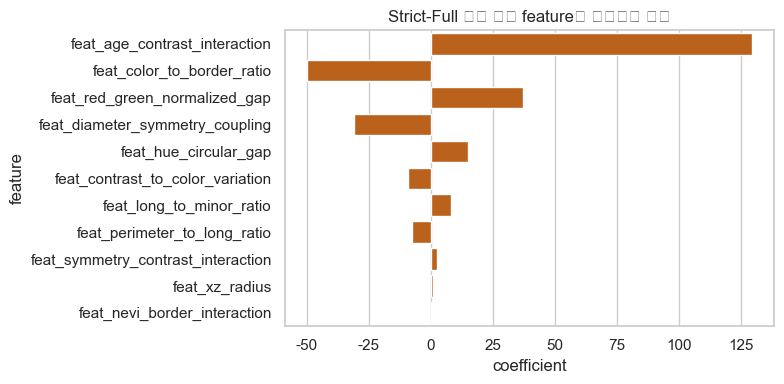

In [7]:
manifest_path = input_dir / 'strict_full_vs_final_strict_feature_manifest.json'
manifest = json.loads(manifest_path.read_text())
strict_only_features = sorted(set(manifest['strict_feature_columns']) - set(manifest['final_strict_feature_columns']))
strict_only_df = coef_df[(coef_df['regime'] == 'strict_full') & (coef_df['feature_name'].isin([f'num__{c}' for c in strict_only_features]))].copy()
strict_only_df['base_feature'] = strict_only_df['feature_name'].str.replace('num__', '', regex=False)
strict_only_df = strict_only_df.sort_values('abs_coefficient', ascending=False)

display(strict_only_df[['base_feature', 'coefficient', 'abs_coefficient']].round(6))

if not strict_only_df.empty:
    plt.figure(figsize=(8, max(4, len(strict_only_df) * 0.35)))
    sns.barplot(data=strict_only_df, y='base_feature', x='coefficient', color=DISPLAY_COLOR['strict_full'])
    plt.title('Strict-Full 전용 추가 feature의 로지스틱 계수')
    plt.xlabel('coefficient')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()


### 해석 포인트
1. 절대 계수가 큰 feature는 baseline에서 더 직접적으로 활용된 feature일 가능성이 큽니다.
2. 다만 계수 크기는 스케일링과 상관관계 구조의 영향도 받으므로 단독으로 과해석하면 안 됩니다.
3. 이 표는 어디까지나 `Strict-Full`의 추가 feature들이 어떤 방향으로 작동했는지 보는 보조 해석용입니다.


## 7. 결론 정리

이 노트북은 아래 질문에 답하기 위해 만들었습니다.
1. `Strict`의 추가 feature 11개가 실제로 성능 향상에 기여하는가?
2. 향상 폭이 있다면, 그 폭이 복잡도 증가를 정당화할 만큼 충분한가?
3. 만약 차이가 작다면 더 단순한 `Strict (최종 메인 세트)`를 baseline으로 삼는 것이 나은가?

다음 단계 제안:
1. 같은 split에서 tree 기반 모델도 동일하게 비교해보기
2. `Strict-Full`과 `Strict`의 오분류 샘플 차이 분석
3. `Relaxed`, `Oracle`까지 같은 프로토콜로 확장하기
